# Student Habits Performance Regression
By John Osorio

The goal is to build a regression model to predict the performance of student according to several factos including social media usage, study hours and sleep.

Based on the public dataset *Student Habits Performance* https://www.kaggle.com/datasets/aryan208/student-habits-and-academic-performance-dataset

## 1. Imports and data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("student_habits_performance.csv")
print(f'rows: {df.shape[0]}, cols: {df.shape[1]}')

rows: 1000, cols: 16


In [ ]:
df.head(5)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [ ]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [ ]:
print("Duplicated rows: ", df.duplicated().sum())

Duplicated rows:  0


## 2. Exploratory Data Analysis

In [ ]:
df = df.drop("student_id", axis=1)

In [ ]:
df["parental_education_level"] = df["parental_education_level"].fillna("Unknown")

In [ ]:
df.isna().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


In [ ]:
#target colum

target_col = 'exam_score'

#categorcal
cat_col = df.select_dtypes(include='object').columns.tolist()

#numerical
num_col = df.select_dtypes(include='number').columns.tolist()

if target_col in num_col:
    num_col.remove(target_col)

print(f"num_col: {num_col} \ncat_col: {cat_col}")

num_col: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating'] 
cat_col: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


Target column distribution

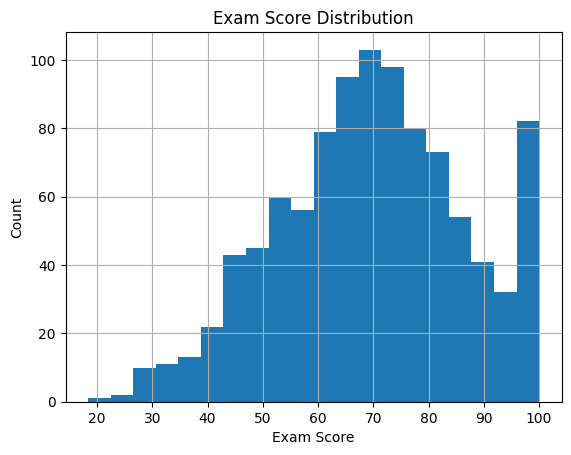

In [ ]:
df[target_col].hist(bins=20)
plt.title("Exam Score Distribution")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()

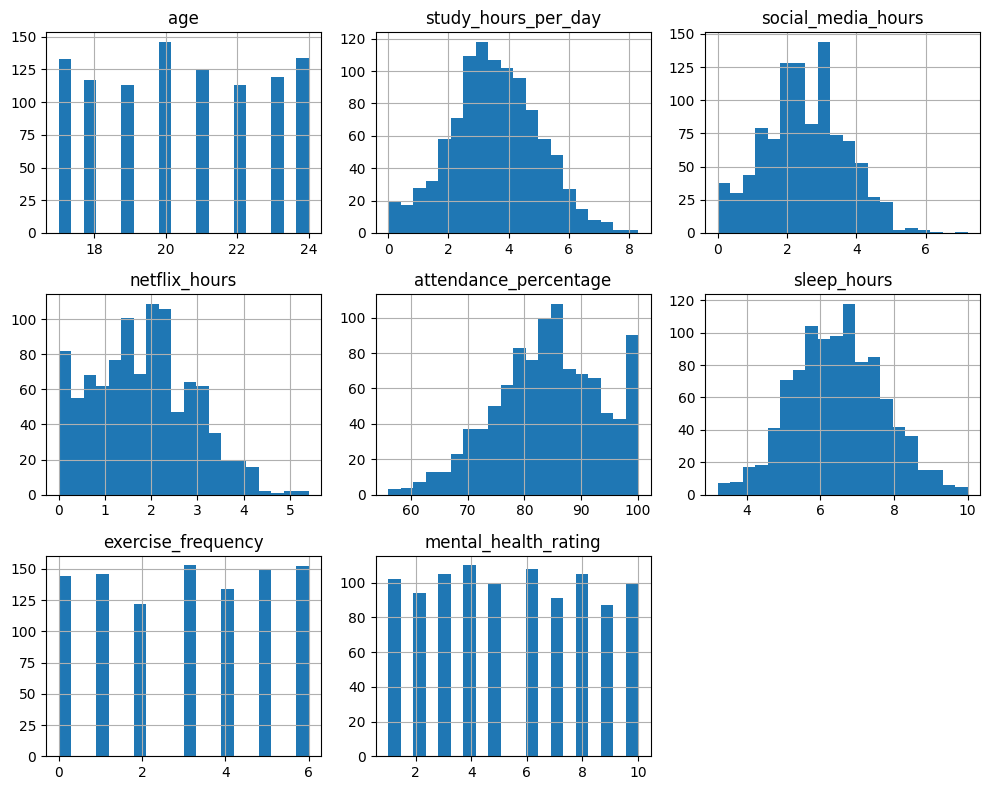

In [ ]:
df[num_col].hist(figsize=(10, 8), bins=20)

plt.tight_layout()
plt.show()

Relationship between target and important features

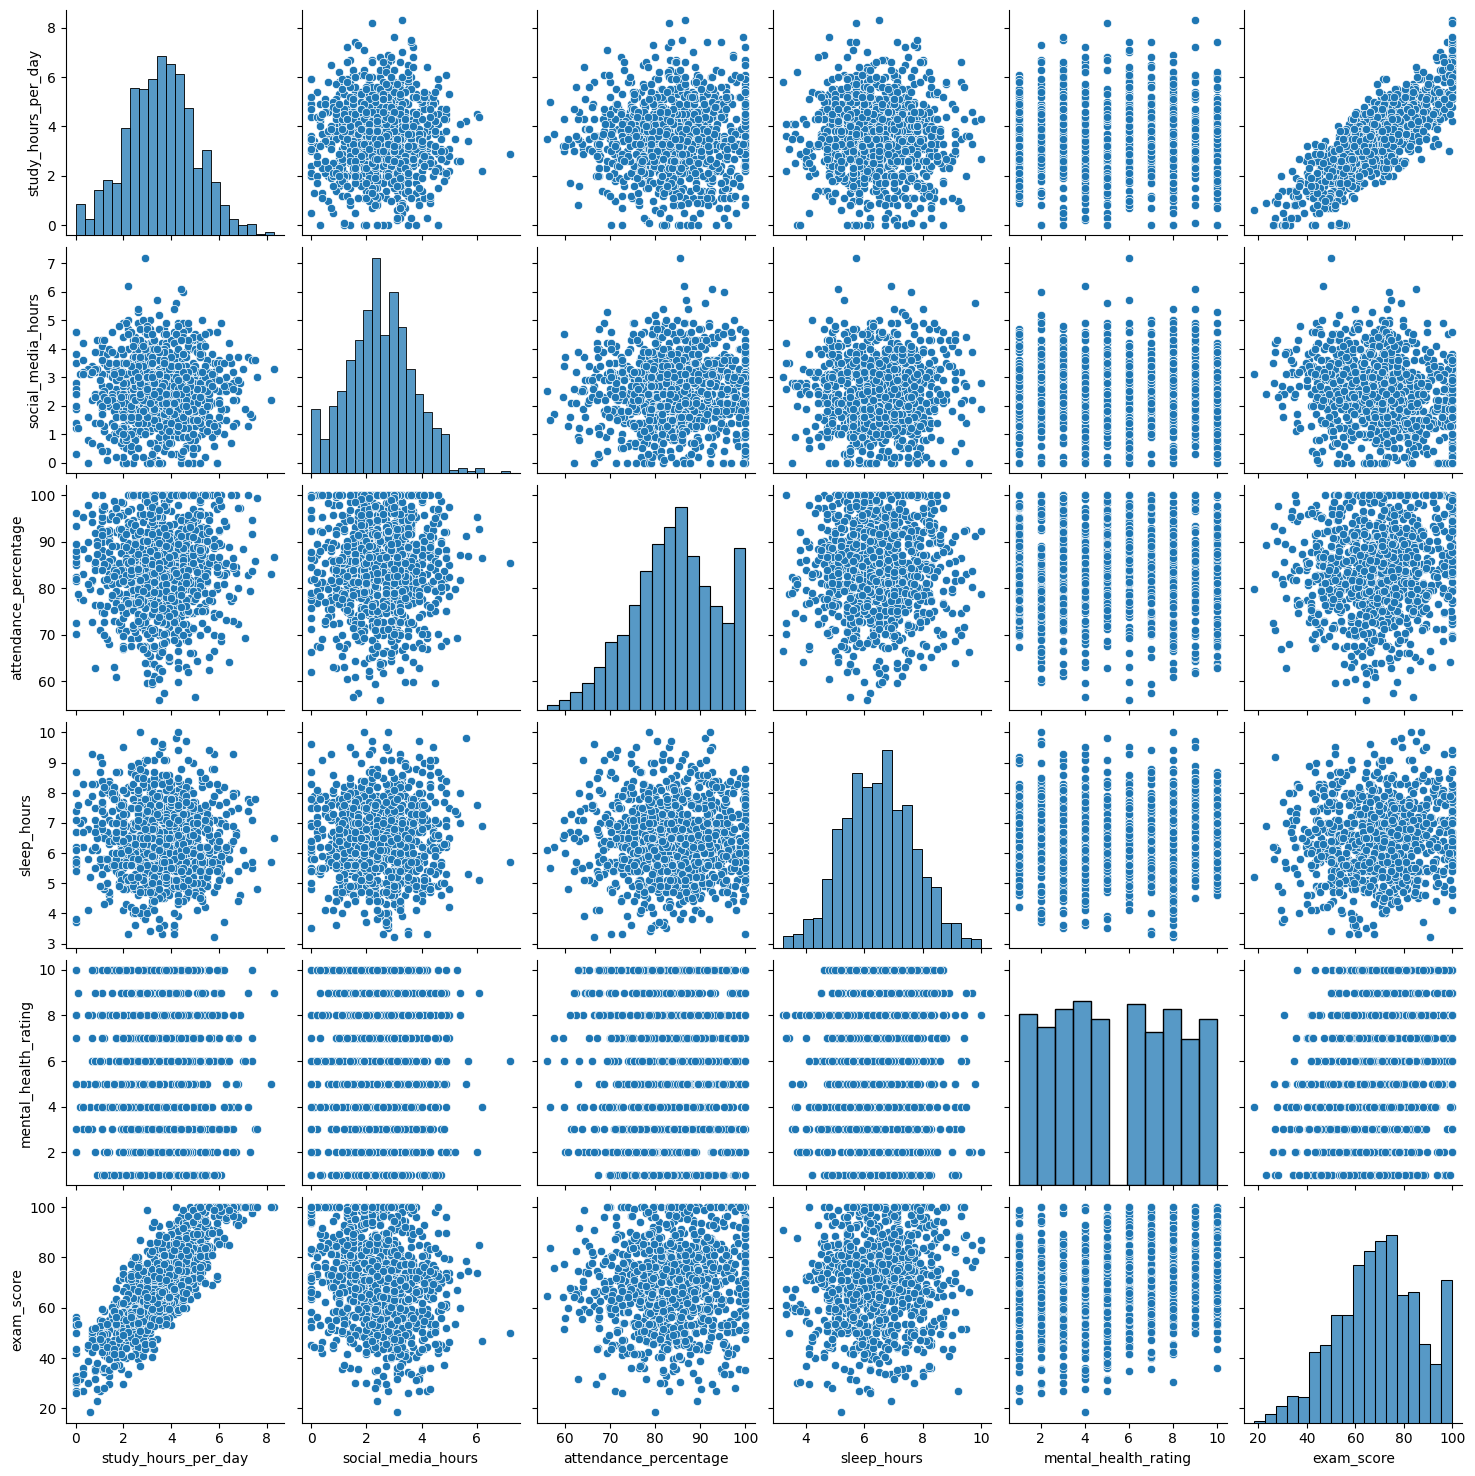

In [ ]:
features = pairplot_cols = ['study_hours_per_day', 'social_media_hours', 'attendance_percentage', 'sleep_hours', 'mental_health_rating']
sns.pairplot(
    df[features + [target_col]],
    kind='scatter',
    diag_kind='hist'
)

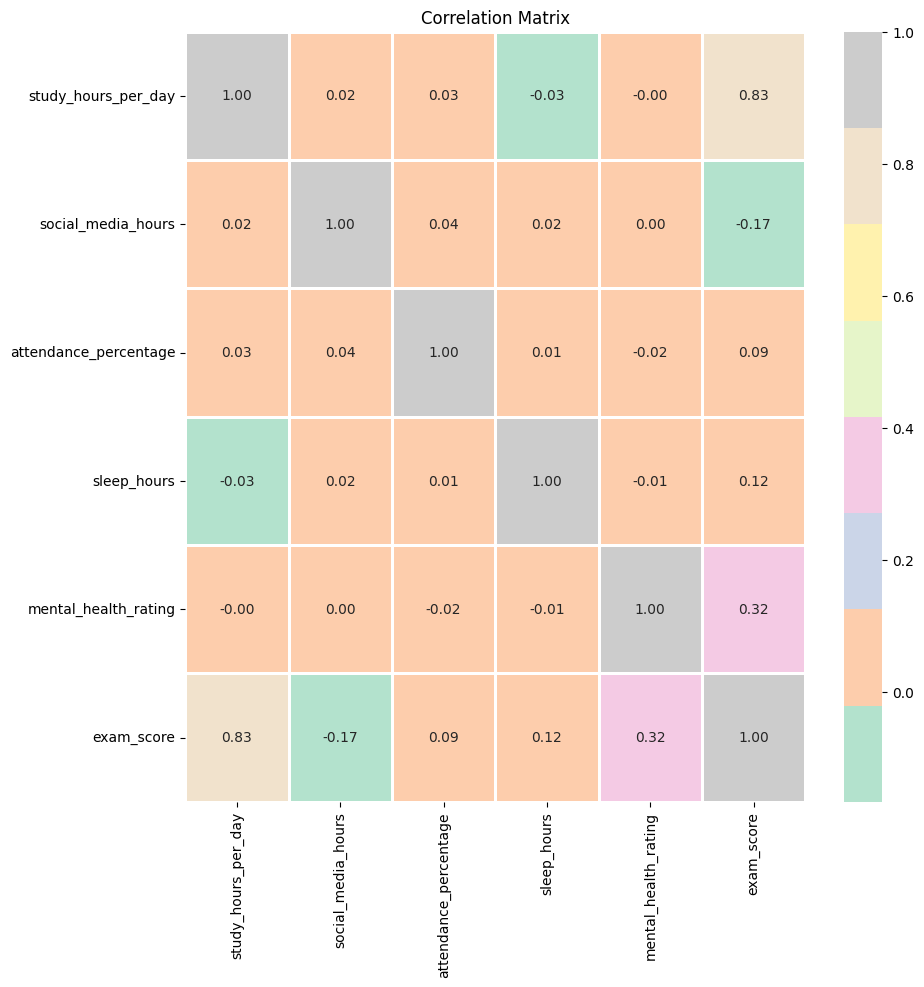

In [ ]:
plt.figure(figsize=(10, 10))

sns.heatmap(df[features+[target_col]].corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Matrix')
plt.show()

As expected, study hours per day show a strong positive correlation (0.83) with exam score.

Distribution of categorical features

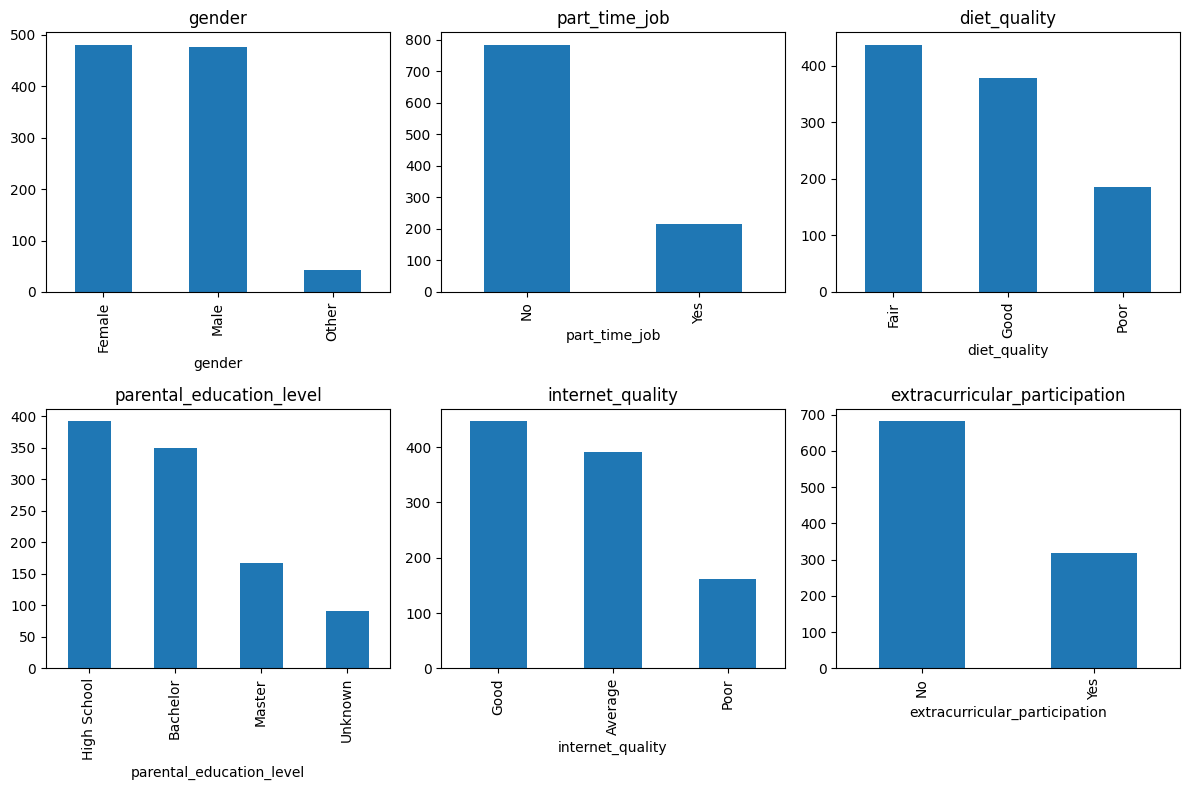

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

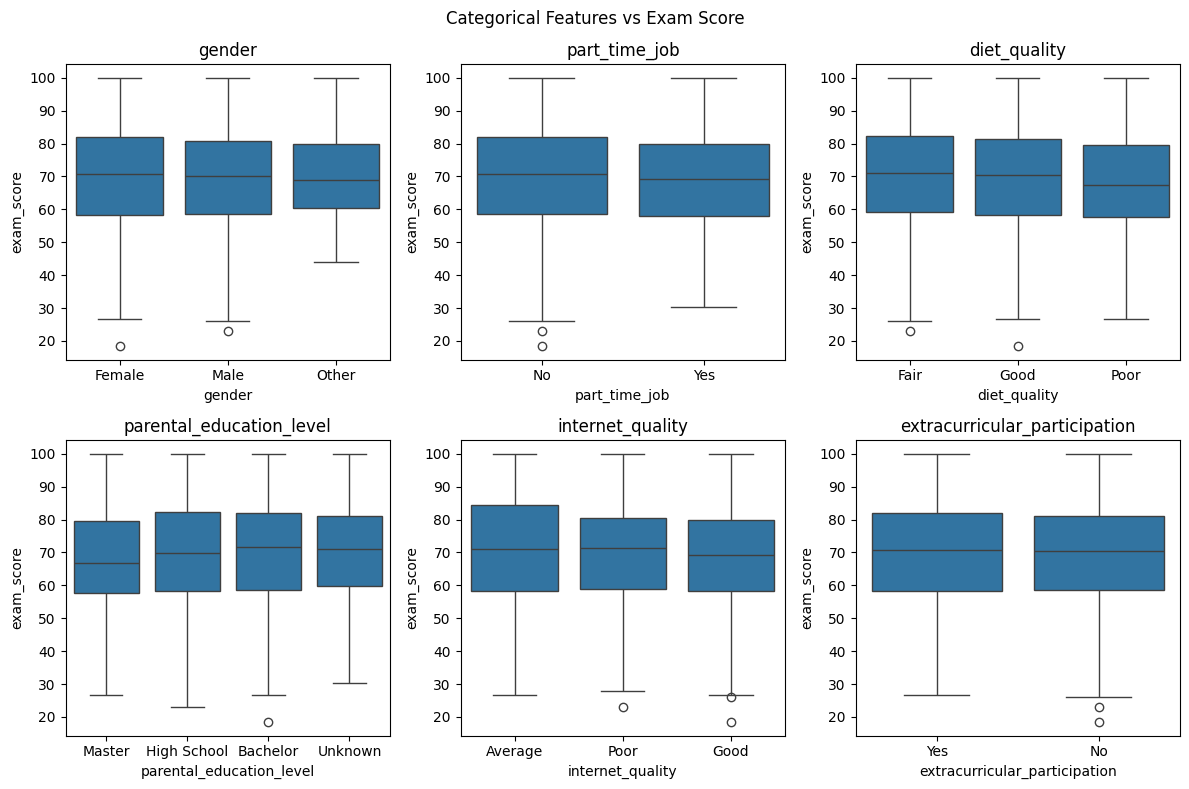

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.boxplot(data=df, x=col, y=target_col, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical Features vs Exam Score")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]

Label encoding for categories and standard scaling for numerical columns

In [ ]:
le = LabelEncoder()
for col in cat_col:
  X[col] = le.fit_transform(X[col])

In [ ]:
scaler = StandardScaler()
X[num_col] = scaler.fit_transform(X[num_col])

In [ ]:
X.head(5)

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
0,1.084551,0,-2.418068,-1.114064,-0.669750,0,0.092426,1.248120,0,1.461166,2,0,0.900186,1
1,-0.215870,0,2.281707,0.251315,0.446965,0,1.401696,-1.525661,1,1.461166,1,0,0.900186,0
2,0.217604,1,-1.464491,0.507324,-0.483631,0,1.135584,1.248120,2,-1.008689,1,2,-1.559339,0
3,1.084551,0,-1.736942,1.190013,-0.762810,0,-1.397800,2.227102,2,0.473224,2,1,-1.559339,1
4,-0.649344,0,0.987566,1.616694,-1.228108,0,0.720450,-1.280916,0,-0.020747,2,1,-1.559339,0


Splitting the dataset for training and testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1234)

## 4. Classification Models

In [ ]:
def eval_model(regressor, X_train, X_test, y_train, y_test):
  regressor.fit(X_train, y_train)
  y_pred = regressor.predict(X_test)
  model_RMSE = root_mean_squared_error(y_test, y_pred)
  model_MAE = mean_absolute_error(y_test, y_pred)
  model_R2 = r2_score(y_test, y_pred)
  return {"RMSE": model_RMSE, "MAE": model_MAE, "R^2": model_R2}

In [ ]:
Models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, max_depth = 3, random_state=1234),
    'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=3, random_state=1234)
}


In [ ]:
results = []
for name, model in Models.items():
  metrics = eval_model(model, X_train, X_test, y_train, y_test)
  metrics = {'Model': name, **metrics}
  results.append(metrics)
models_metrics = pd.DataFrame(results)

In [ ]:
models_metrics.sort_values(by="R^2", ascending=False)

,Model,RMSE,MAE,R^2
2,Lasso,5.423878,4.378350,0.898101
0,LinearRegression,5.432726,4.372217,0.897768
1,Ridge,5.433081,4.373035,0.897755
3,RandomForestRegressor,8.861479,7.248560,0.728004
4,DecisionTreeRegressor,9.487716,7.642673,0.688201
